In [ ]:
%pip install pennylane --quiet

In [2]:
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

In [ ]:
N_train, N_test = 10_000, 100
u0, rho, Re = 1.0, 1.0, 100
shots = None
n_qubits = 4

In [3]:
torch.manual_seed(42)
np.random.seed(42)

classic_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_device = qml.device("default.qubit", wires=n_qubits, shots=shots)
print(f"Using devices: {classic_device}, {q_device}")

Using device: cpu


In [6]:
"""
-----------------------------
Quantum layer definition
-----------------------------
"""


class QuantumLayer(nn.Module):
    def __init__(self, n_qubits: int, n_layers: int, shots=None):
        super().__init__()
        weights = qml.StronglyEntanglingLayers.shape(
            n_layers=n_layers, n_wires=n_qubits
        )

        self.n_qubits = n_qubits
        self.n_layers = n_layers
        qnode = self.make_circuit(q_device)
        self.layer = qml.qnn.TorchLayer(qnode, {"weights": weights})  # type: ignore

    def forward(self, x):
        return self.layer(x)

    @staticmethod
    def make_circuit(q_device):
        @qml.qnode(q_device, interface="torch", diff_method="backprop")
        def qnode(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        return qnode

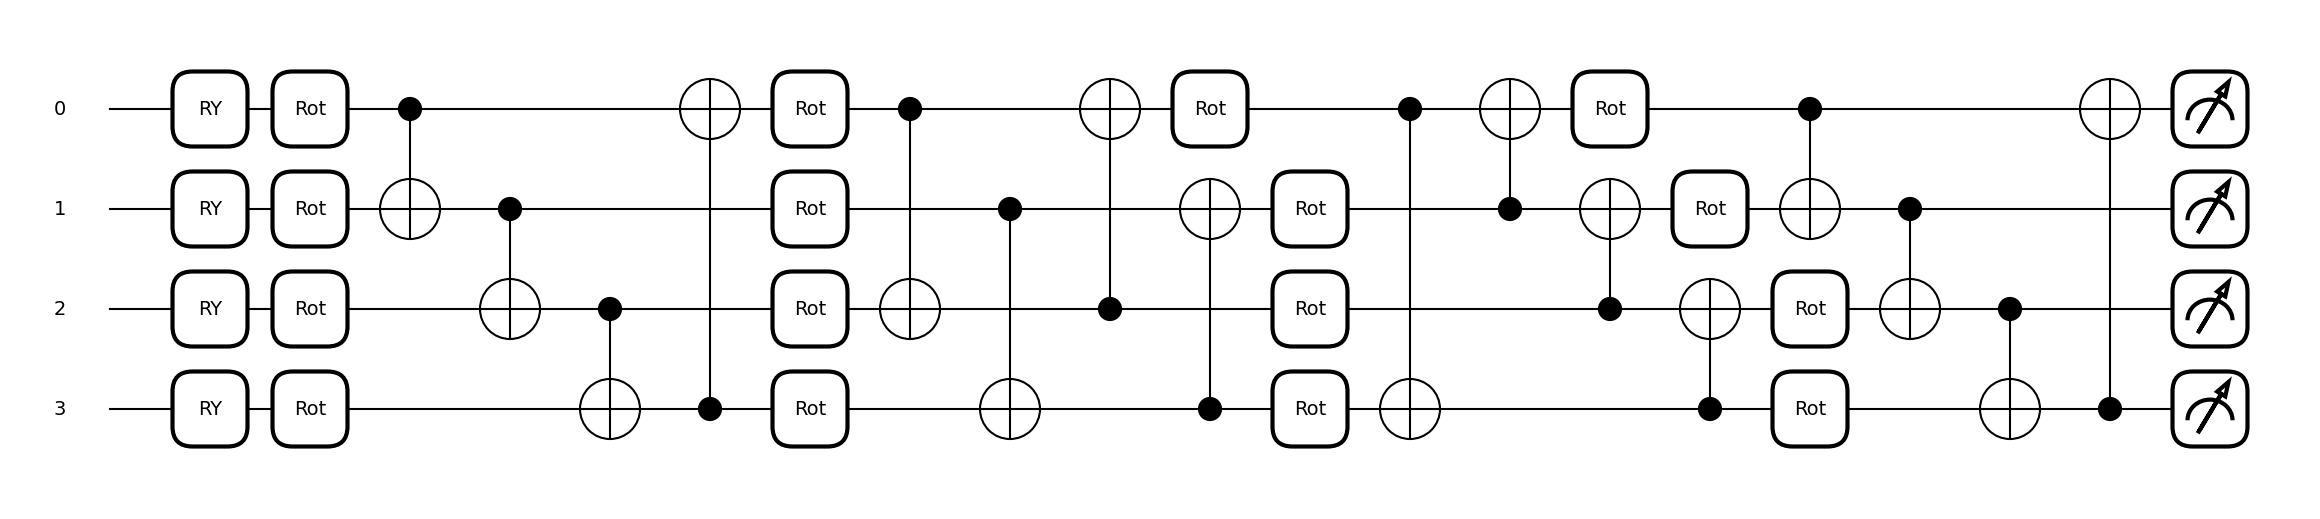

In [10]:
qml.drawer.use_style("black_white")  # type: ignore
dummy_inputs = torch.zeros(n_qubits)
dummy_weights = torch.zeros(4, n_qubits, 3)
fig, ax = qml.draw_mpl(
    QuantumLayer.make_circuit(q_device),
    level="device"
)(dummy_inputs, dummy_weights)
plt.show()

In [ ]:
class HybridQPINN(nn.Module):
    def __init__(self, q_layer: QuantumLayer, hidden_dim: int = 32):
        super().__init__()
        self.quantum = q_layer

        self.embedding = nn.Sequential(
            nn.Linear(2, q_layer.n_qubits),
            nn.Tanh(),
        )

        self.decoding = nn.Sequential(
            nn.Linear(q_layer.n_qubits, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

        for nets in [self.embedding, self.decoding]:
            for m in nets:
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                    nn.init.zeros_(m.bias)

    def forward(self, xy):
        # default.qubit is a CPU-only statevector simulator; the round-trip is unavoidable.
        device = xy.device
        x = self.embedding(xy)
        x = self.quantum(x.cpu())   # simulate on CPU
        return self.decoding(x.to(device))

In [ ]:
"""
------------------------------
Calculate the params
------------------------------
"""


def make_hybrid_qpinn(n_qubits: int, n_layers: int, shots=None, hidden_dim: int = 32):
    q_layer = QuantumLayer(n_qubits=n_qubits, n_layers=n_layers, shots=shots)
    model = HybridQPINN(q_layer=q_layer, hidden_dim=hidden_dim)
    return model.to(classic_device)


def count_trainable_params(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def qpinn_param_breakdown(
    n_qubits: int,
    n_layers: int,
    shots=None,
    hidden_dim: int = 32,
):
    model = make_hybrid_qpinn(
        n_qubits=n_qubits,
        n_layers=n_layers,
        shots=shots,
        hidden_dim=hidden_dim,
    )
    breakdown = {
        "embedding": count_trainable_params(model.embedding),
        "quantum": count_trainable_params(model.quantum),
        "decoding": count_trainable_params(model.decoding),
    }
    breakdown["total"] = sum(breakdown.values())
    return breakdown


current_params = qpinn_param_breakdown(
    n_qubits=n_qubits,
    n_layers=3,
    shots=shots,
    hidden_dim=32,
)
print("Parameter breakdown (current setup):", current_params)


param_table = []
for nq in range(2, 5):
    for nl in range(3, 10, 2):
        b = qpinn_param_breakdown(n_qubits=nq, n_layers=nl, shots=shots, hidden_dim=32)
        param_table.append(
            (nq, nl, b["embedding"], b["quantum"], b["decoding"], b["total"])
        )


print(
    "\nQPINN parameter scan (n_qubits, n_layers, embedding, quantum, decoding, total)"
)
for row in param_table:
    print(row)

In [ ]:
"""
-----------------------------
PDE residuals and gradients
-----------------------------
"""

def d_(f, v):
    return torch.autograd.grad(
        f, v, grad_outputs=torch.ones_like(f), create_graph=True
    )[0]


def model_grads(model, xy):
    out = model(xy)
    psi = out[:, :1]
    p = out[:, 1:2]

    grad_psi = d_(psi, xy)
    u = grad_psi[:, 1:2]
    v = -grad_psi[:, 0:1]

    grad_p = d_(p, xy)
    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    grad_u = d_(u, xy)
    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    u_xx = d_(u_x, xy)[:, 0:1]
    u_yy = d_(u_y, xy)[:, 1:2]

    grad_v = d_(v, xy)
    v_x = grad_v[:, 0:1]
    v_y = grad_v[:, 1:2]
    v_xx = d_(v_x, xy)[:, 0:1]
    v_yy = d_(v_y, xy)[:, 1:2]

    return {
        "psi": psi,
        "p": p,
        "u": u,
        "v": v,
        "p_x": p_x,
        "p_y": p_y,
        "u_x": u_x,
        "u_y": u_y,
        "u_xx": u_xx,
        "u_yy": u_yy,
        "v_x": v_x,
        "v_y": v_y,
        "v_xx": v_xx,
        "v_yy": v_yy,
    }


def pde_residuals(fields, rho=1.0, nu=0.01):
    u, v = fields["u"], fields["v"]
    u_x, u_y = fields["u_x"], fields["u_y"]
    v_x, v_y = fields["v_x"], fields["v_y"]
    p_x, p_y = fields["p_x"], fields["p_y"]
    u_xx, u_yy = fields["u_xx"], fields["u_yy"]
    v_xx, v_yy = fields["v_xx"], fields["v_yy"]

    mom_x = u * u_x + v * u_y + p_x / rho - nu * (u_xx + u_yy)
    mom_y = u * v_x + v * v_y + p_y / rho - nu * (v_xx + v_yy)
    return mom_x, mom_y

In [ ]:
"""
------------------------------
Loss function definition
------------------------------
"""

mse = nn.MSELoss()

def compute_loss(model, xy_eqn, xy_bnd, uv_bnd, rho=1.0, nu=0.01):
    fields_eqn = model_grads(model, xy_eqn)
    mom_x, mom_y = pde_residuals(fields_eqn, rho=rho, nu=nu)
    loss_eqn = mse(mom_x, torch.zeros_like(mom_x)) + mse(
        mom_y, torch.zeros_like(mom_y)
    )

    fields_bnd = model_grads(model, xy_bnd)
    psi_bc = fields_bnd["psi"]
    uv_bc = torch.cat([fields_bnd["u"], fields_bnd["v"]], dim=1)
    loss_psi = mse(psi_bc, torch.zeros_like(psi_bc))
    loss_uv = mse(uv_bc, uv_bnd)

    loss = loss_eqn + loss_psi + loss_uv
    return loss

In [ ]:
"""
------------------------------
Training loop (same style as classical PINN)
------------------------------
"""

def train_qpinn(
    model,
    xy_eqn,
    xy_bnd,
    uv_bnd,
    rho=1.0,
    nu=0.01,
    adam_iters=500,
    lbfgs_iters=200,
    adam_lr=1e-3,
    print_every=50,
    clip_grad=1.0,
    batch_size=256,
):
    history = []

    n_eqn = xy_eqn.shape[0]
    n_bnd = xy_bnd.shape[0]

    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    print(f"Starting Adam (batch_size={batch_size})...")

    for i in range(adam_iters):
        # ---- mini-batch sampling ----
        idx_e = torch.randint(0, n_eqn, (min(batch_size, n_eqn),), device=xy_eqn.device)
        idx_b = torch.randint(0, n_bnd, (min(batch_size, n_bnd),), device=xy_bnd.device)

        xy_e_batch = xy_eqn[idx_e].detach().requires_grad_(True)
        xy_b_batch = xy_bnd[idx_b].detach().requires_grad_(True)
        uv_b_batch = uv_bnd[idx_b]

        adam.zero_grad()
        loss = compute_loss(model, xy_e_batch, xy_b_batch, uv_b_batch, rho=rho, nu=nu)
        loss.backward()
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        adam.step()

        history.append(loss.item())
        if (i + 1) % print_every == 0 or i == 0:
            print(f"[Adam {i + 1}/{adam_iters}] loss={loss.item():.4e}")

    print(f"[Adam done] loss={history[-1]:.4e}\n")

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        max_iter=lbfgs_iters,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe",
    )

    lbfgs_step = [0]

    def closure_for_lbfgs():
        lbfgs.zero_grad()
        loss = compute_loss(model, xy_eqn, xy_bnd, uv_bnd, rho=rho, nu=nu)
        loss.backward()
        if (lbfgs_step[0] + 1) % print_every == 0 or lbfgs_step[0] == 0:
            print(f"[LBFGS {lbfgs_step[0] + 1}/{lbfgs_iters}] loss={loss.item():.4e}")
        lbfgs_step[0] += 1
        return loss

    print("Starting LBFGS (full dataset)...")
    lbfgs.step(closure_for_lbfgs)

    final_loss = closure_for_lbfgs().item()
    model.zero_grad(set_to_none=True)
    history.append(final_loss)
    print(f"[LBFGS done] loss={final_loss:.4e}")

    return history

In [ ]:
def generate_bc_points(n_total):
    n = n_total // 4
    top = np.hstack([np.random.rand(n, 1), np.ones((n, 1))])
    bottom = np.hstack([np.random.rand(n, 1), np.zeros((n, 1))])
    left = np.hstack([np.zeros((n, 1)), np.random.rand(n, 1)])
    right = np.hstack([np.ones((n, 1)), np.random.rand(n, 1)])
    return np.vstack([top, bottom, left, right]).astype(np.float32)


xy_bnd_np = generate_bc_points(N_train)
xy_eqn_np = np.random.rand(N_train, 2).astype(np.float32)

uv_bnd_np = np.zeros((N_train, 2), dtype=np.float32)
is_top_wall = np.isclose(xy_bnd_np[:, 1], 1.0)
uv_bnd_np[is_top_wall, 0] = u0

xy_eqn = torch.tensor(xy_eqn_np, requires_grad=True, device=classic_device)
xy_bnd = torch.tensor(xy_bnd_np, requires_grad=True, device=classic_device)
uv_bnd = torch.tensor(uv_bnd_np, device=classic_device)

model = make_hybrid_qpinn(
    n_qubits=n_qubits,
    n_layers=3,
    hidden_dim=32,
    shots=shots,
)

loss_history = train_qpinn(
    model,
    xy_eqn,
    xy_bnd,
    uv_bnd,
    rho=rho,
    nu=1 / Re,
    adam_iters=500,
    lbfgs_iters=200,
    adam_lr=1e-3,
    print_every=50,
    clip_grad=1.0,
)

In [ ]:
def contour(grid, x, y, z, title, levels=40):
    vmin, vmax = z.min(), z.max()
    plt.subplot(grid)
    plt.contour(x, y, z, colors="k", linewidths=0.2, levels=levels)
    plt.contourf(
        x, y, z, cmap="rainbow", levels=levels,
        norm=Normalize(vmin=vmin, vmax=vmax),
    )
    plt.title(title)
    cbar = plt.colorbar(pad=0.03, aspect=25, format="%.0e")
    cbar.mappable.set_clim(vmin, vmax)


# Prediction grid
x_lin = np.linspace(0, 1, N_test, dtype=np.float32)
y_lin = np.linspace(0, 1, N_test, dtype=np.float32)
X, Y = np.meshgrid(x_lin, y_lin)
XY = np.stack([X.ravel(), Y.ravel()], axis=1)

xy_test = torch.tensor(XY, device=classic_device)
xy_test.requires_grad_(True)
fields = model_grads(model, xy_test)

psi = fields["psi"].detach().cpu().numpy().reshape(X.shape)
p = fields["p"].detach().cpu().numpy().reshape(X.shape)
u = fields["u"].detach().cpu().numpy().reshape(X.shape)
v = fields["v"].detach().cpu().numpy().reshape(X.shape)

In [ ]:
# Visualization 1: contour panel
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2)
contour(gs[0, 0], X, Y, psi, "Stream Function (psi)")
contour(gs[0, 1], X, Y, p, "Pressure (p)")
contour(gs[1, 0], X, Y, u, "Horizontal Velocity (u)")
contour(gs[1, 1], X, Y, v, "Vertical Velocity (v)")
plt.tight_layout()
plt.show()

# Ghia reference (u along x=0.5, Re=100)
y_u = np.array([
    1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344,
    0.6172, 0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703,
    0.0625, 0.0547, 0.0000
], dtype=np.float32)
u_Re100 = np.array([
    1.00000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332,
    -0.13641, -0.20581, -0.21090, -0.15662, -0.10150, -0.06434,
    -0.04775, -0.04192, -0.03717, 0.00000
], dtype=np.float32)

# Visualization 2
fig, axs = plt.subplots(2, 2, figsize=(9, 7))

cf = axs[0, 0].contourf(X, Y, p, levels=50, cmap="rainbow")
plt.colorbar(cf, ax=axs[0, 0])
stride = 5
axs[0, 0].quiver(
    X[::stride, ::stride], Y[::stride, ::stride],
    u[::stride, ::stride], v[::stride, ::stride], color="k"
    )
axs[0, 0].set_title("Pressure with Velocity Vectors")

axs[0, 1].streamplot(
    X, Y, u, v, color=np.sqrt(u**2 + v**2), cmap="viridis", linewidth=1
    )
axs[0, 1].set_title("Streamplot of Velocity Field")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")

mid_x = np.argmin(np.abs(x_lin - 0.5))
axs[1, 0].plot(u[:, mid_x], y_lin, label="Predicted")
axs[1, 0].plot(u_Re100, y_u, "o", label="Ghia reference")
axs[1, 0].set_title("u-velocity Profile at x=0.5")
axs[1, 0].set_xlabel("u")
axs[1, 0].set_ylabel("y")
axs[1, 0].legend()

axs[1, 1].semilogy(loss_history)
axs[1, 1].set_title("Training Loss Convergence")
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

In [ ]:
import time


def _sync_if_cuda(device):
    if device.type == "cuda":
        torch.cuda.synchronize()


def _summarize_ms(timings_s, repeats, num_points):
    timings_ms = np.array(timings_s, dtype=np.float64) * 1000.0
    return {
        "mean_ms": float(timings_ms.mean()),
        "std_ms": float(timings_ms.std()),
        "min_ms": float(timings_ms.min()),
        "max_ms": float(timings_ms.max()),
        "repeats": int(repeats),
        "num_points": int(num_points),
    }


def benchmark_prediction(
    model,
    xy_np,
    device,
    repeats=30,
    warmup=5,
    with_derivatives=True,
    use_no_grad_forward=True,
):
    model.eval()
    timings = []

    for i in range(warmup + repeats):
        xy = torch.tensor(xy_np, device=device)
        if with_derivatives:
            xy.requires_grad_(True)

        _sync_if_cuda(device)
        t0 = time.perf_counter()

        if with_derivatives:
            out = model_grads(model, xy)
            _ = out["u"].mean() + out["v"].mean() + out["p"].mean()
        else:
            if use_no_grad_forward:
                with torch.no_grad():
                    out = model(xy)
                    _ = out.mean()
            else:
                out = model(xy)
                _ = out.mean()

        _sync_if_cuda(device)
        dt = time.perf_counter() - t0
        if i >= warmup:
            timings.append(dt)

    return _summarize_ms(timings, repeats, xy_np.shape[0])


# Reuse XY from previous prediction cell if available; otherwise rebuild it.
if "XY" not in globals():
    x_lin = np.linspace(0, 1, N_test, dtype=np.float32)
    y_lin = np.linspace(0, 1, N_test, dtype=np.float32)
    X, Y = np.meshgrid(x_lin, y_lin)
    XY = np.stack([X.ravel(), Y.ravel()], axis=1).astype(np.float32)

forward_stats = benchmark_prediction(
    model,
    XY,  # type: ignore
    classic_device,
    repeats=30,
    warmup=5,
    with_derivatives=False,
    use_no_grad_forward=True,
)
physics_stats = benchmark_prediction(
    model,
    XY,  # type: ignore
    classic_device,
    repeats=30,
    warmup=5,
    with_derivatives=True,
)

print("Forward-only prediction timing (model(x,y) -> [psi,p]):")
print(
    f"  {forward_stats['mean_ms']:.3f} +/- {forward_stats['std_ms']:.3f} ms "
    f"(min={forward_stats['min_ms']:.3f}, max={forward_stats['max_ms']:.3f}, "
    f"runs={forward_stats['repeats']}, points={forward_stats['num_points']})"
)

print(
    "\nPrediction with derivatives timing (model_grads for u,v,p and spatial derivatives):"
)
print(
    f"  {physics_stats['mean_ms']:.3f} +/- {physics_stats['std_ms']:.3f} ms "
    f"(min={physics_stats['min_ms']:.3f}, max={physics_stats['max_ms']:.3f}, "
    f"runs={physics_stats['repeats']}, points={physics_stats['num_points']})"
)